In [251]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [252]:
def f(x):
    return 3*x**2 - 4*x + 5

In [253]:
f(3.0)

20.0

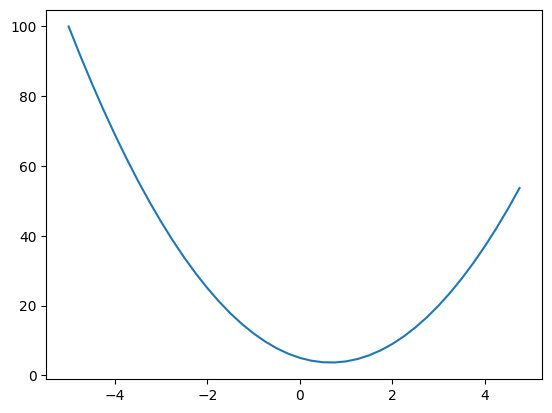

20.0

In [254]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)
plt.show()
def f(x):
    return 3*x**2 - 4*x + 5
f(3.0)

In [255]:
h = 0.00001
x = 3.0
(f(x+h) - f(x)) / h # 6x-4 = 14

14.00003000000538

In [256]:
h = 0.00001
x = -3.0
(f(x+h) - f(x)) / h # 6x-4 = -22

-21.999970000052823

In [257]:
h = 0.0000001
x = 2/3
(f(x+h) - f(x)) / h # 6x-4 = 0

2.9753977059954195e-07

In [258]:
# More complex example

h = 0.0000001

a = 2.0
b = -3.0
c = 10.0
d = a*b + c

print(d)


4.0


In [259]:
h = 0.0000001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h)



d1 4.0
d2 3.9999997
slope -2.9999999995311555


In [260]:
h = 0.0000001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
b += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h)

d1 4.0
d2 4.0000002
slope 1.9999999967268423


In [261]:
h = 0.0000001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h)

d1 4.0
d2 4.000000099999999
slope 0.999999993922529


In [345]:
# Build value class

class Value:
    def __init__(self, data, _children=(), _op='', label=''): # children set up graph
        self.data = data
        self.grad = 0.0 # No effect on output
        self._backward = lambda: None # Build the chain rule here
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"
    # Important to know how to get local derivatives even if use complex fn.
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) # consider int if not Value
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward(): # gradients just get copied backwards for addition operation
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other
    
    def __neg__(self):
        return -1 * self

    def __sub__(self, other):
        return self + (-other)
    

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) # consider int if not Value
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other): # check if other * self so 2*Value -> use here as 2.__mul__ not recognize Value type
        return self * other
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)) # Make sure power is either int or float
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data**(other-1)) * out.grad
        out._backward = _backward

        return out
    
    def __truediv__(self, other):
        return self * other ** -1
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out
    
    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
    
    # a/b = a* (1/b) = a * (b**-1)
    
    def backward(self):
        visited = set()
        topo = []
        # start at o and then go through all children from right to left
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v) # current node add only after all children have been processed
        build_topo(self)
        self.grad = 1 # starting point
        for node in reversed(topo):
            node._backward()

In [263]:
a = Value(2.0, label='a')
a

Value(data=2.0)

In [264]:
a = Value(2.0, label='a')
b = Value(4.0, label='a')
a/b

Value(data=0.5)

In [265]:
b - a

Value(data=2.0)

In [266]:
a*2

Value(data=4.0)

In [267]:
2*a # call rmul that calls a*2

Value(data=4.0)

In [268]:
b = Value(3.0, label='b')
a + b

Value(data=5.0)

In [269]:
a.__add__(b)

Value(data=5.0)

In [270]:
a * b

Value(data=6.0)

In [271]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'


In [272]:
d._prev, d._op, d.label


({Value(data=-6.0), Value(data=10.0)}, '+', 'd')

In [273]:
# Visualize Value class
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


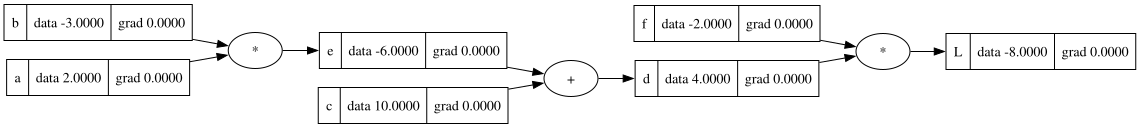

In [274]:
draw_dot(L) # Forward pass

# Run backprop

In [275]:

# Derivative of each node with respect to L; NN setting for L -> wts updated based on gradiant information -> derviate of L wrt to each step
# recursivily multiply local derivatives along the path
L.grad = 1
d.grad = -2
f.grad = 4
c.grad = -2
e.grad = -2
a.grad = 6
b.grad = -4

In [276]:
# dL/dc = dL/dd * dd/dc # chain rule = -2*1 = -2; + routes the gradient back
# dL/da = de/da * dd/de * dL/dd = -3*-2 = 6

In [277]:
def lol(): # derivative wrt L
    h = 0.0000001
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d*f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0+h, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d*f; L.label = 'L'
    L2 = L.data

    return (L2 - L1) / h

lol()

-3.9999999934536845

In [278]:
# If move in direction of gradient, impact of L in positive direction from -8; 1 step of optimization
a.data += 0.01*a.grad
b.data += 0.01*b.grad
c.data += 0.01*c.grad
f.data += 0.01*f.grad


In [279]:
# Rerun forward pass
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
L = d*f; L.label = 'L'

In [280]:
L.data

-7.286496

# Backpropogate through a neuron

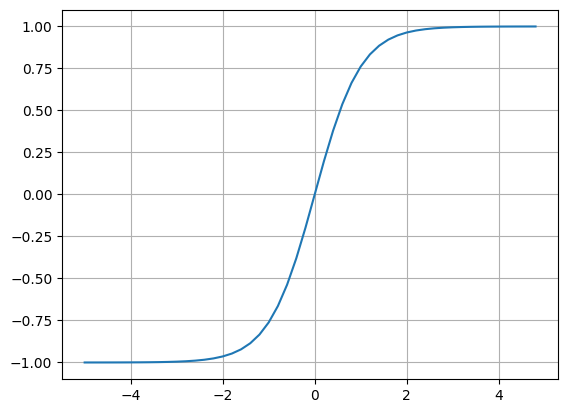

In [281]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid(); # squashing fn at very positive / negative values

In [282]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o' # Similar to + / - -> exponential fn.
o

Value(data=0.7071067811865476)

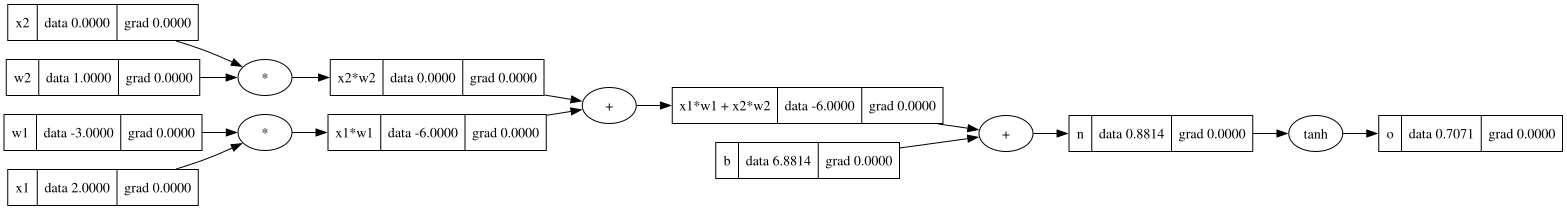

In [283]:
draw_dot(o)

In [284]:
# Backward method defined
o.backward()

In [285]:
# Call backward
# Initialize o.grad = 1 else set as 0 by default
o.grad = 1
o._backward()
n._backward()
x1w1x2w2._backward()
b._backward() # By initialization, None
x1w1._backward()
x2w2._backward()

In [286]:
# derivative of neurons on weights -> those we can change for optimization.
o.grad = 1
n.grad = 1 - o.data**2
b.grad = n.grad * 1
x1w1x2w2.grad = n.grad * 1
x1w1.grad = x1w1x2w2.grad * 1 # Output of neuron to inc, then this has positive effect
x2w2.grad = x1w1x2w2.grad * 1
x1.grad = x1w1.grad * w1.data
w1.grad = x1w1.grad * x1.data # If w1 go up, output will go up proportionally as grad is 1
x2.grad = x2w2.grad * w2.data
w2.grad = x2w2.grad * x2.data

In [287]:
# o = tanh(n)
# do/dn = 1 - tanh(n)^2

In [288]:
# Call backward on all nodes in topological order
o.grad = 1 # base case

# Ordering of graph -> Topological sort -> all edges go in one way from left to right - allows chain rule to propogate from one end to other

topo = []
visited = set()

# start at o and then go through all children from right to left
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v) # current node add only after all children have been processed
build_topo(o)

for node in reversed(topo):
    node._backward()

In [289]:
topo 

[Value(data=6.881373587019543),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

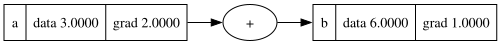

In [290]:
# Bug if we dont accumulate gradients when same variable name is used
a = Value(3.0, label = 'a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

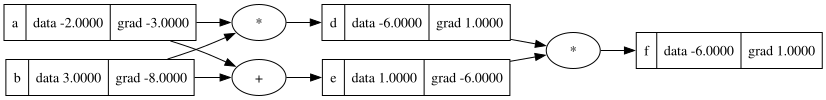

In [291]:
# Another example
a = Value(-2.0, label = 'a')
b = Value(3.0, label = 'b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'
f.backward()
draw_dot(f)

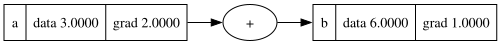

In [292]:
# Fixed
a = Value(3.0, label = 'a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

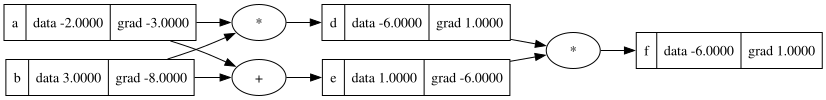

In [293]:
# Another example
a = Value(-2.0, label = 'a')
b = Value(3.0, label = 'b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'
f.backward()
draw_dot(f)

# Tanh broken down 

In [294]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
#o = n.tanh(); o.label = 'o' # Similar to + / - -> exponential fn.
e = (2*n).exp(); e.label = 'e' 
o = (e-1) / (e+1); o.label = 'o'
o

Value(data=0.7071067811865477)

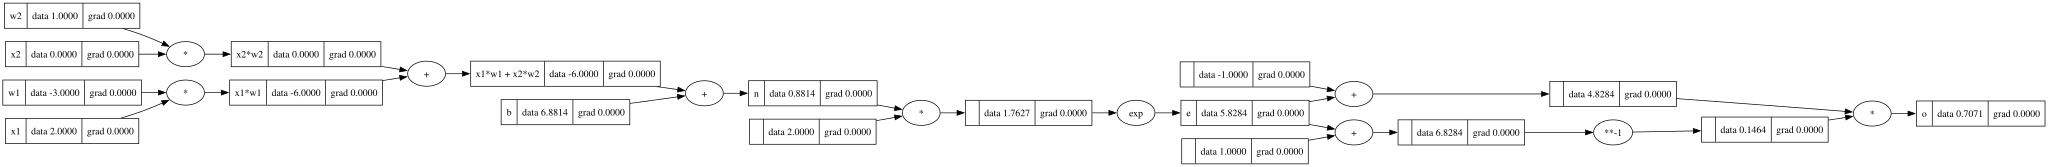

In [295]:
draw_dot(o)

In [296]:
o.backward()

# Build Multi Layer Perceptron

In [297]:
class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # wx + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

In [298]:
x = [2.0, 3.0]
n = Neuron(2)
n(x)


Value(data=0.8595242879443378)

In [299]:
class Layer:
    
    def __init__(self, nin, nout): # nin number of dimensions per neuron, nout number of neurons per layer
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        # p = []
        # for n in self.neurons:
        #     p.extend(n.parameters())
        # return p

In [300]:
x = [2.0, 3.0]
n = Layer(3, 4)
n(x)

[Value(data=-0.7854231562989081),
 Value(data=-0.6210550918369104),
 Value(data=0.8486942988393678),
 Value(data=0.6850301852825313)]

In [301]:
class MLP:

    def __init__(self, nin, nouts): # nin is number of inputs, nouts -> list -> size of all layers in MLP
        sz = [nin] + nouts

        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        # p = []
        # for layer in self.layers:
        #     p.extend(layer.parameters())
        # return p

In [302]:
# MLP with 3 inputs, 2 hidden layer and 1 output layer
x = [2.0, 3.0, 4.0]
m = MLP(3, [4, 4, 1])
m(x)

Value(data=0.9582569283652886)

In [303]:
len(m.parameters())

41

In [304]:
#draw_dot(m(x))

In [305]:
# Simple example with 4 inputs and 4 targets

xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [306]:
ypred = [m(x) for x in xs]
ypred

[Value(data=0.8865943197224363),
 Value(data=0.8776832846488618),
 Value(data=0.9326401834489797),
 Value(data=0.8711618061150532)]

In [307]:
# Calculate single number that measures total performance of NN -> Loss ( Minimize loss)
[(yout-ygt)**2 for ygt, yout in zip(ys, ypred)] # Mean Square Error

[Value(data=0.012860848319217001),
 Value(data=3.5256945174497387),
 Value(data=3.735098078681706),
 Value(data=0.016599280203535134)]

In [308]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred)) # Sum of Mean Square Error
loss

Value(data=7.290252724654197)

In [309]:
loss.backward()

In [310]:
m.layers[0].neurons[0].w[0].grad # Inc grad from 0.61 then lead to inc in loss -> we want to do opp to dec loss

0.07367888366656841

In [311]:
m.layers[0].neurons[0].w[0].data

0.9630326283024577

In [312]:
#draw_dot(loss)

In [313]:
# gradients on input data not useful as they wont change, the ones for w and b values can change based on gradient
for p in m.parameters():
    p.data = p.data - 0.1 * p.grad # Grad descent - modify in step wise direction of gradient; grad direction in increasing loss but we wont to dec loss (-ve to minimize loss)

In [314]:
m.layers[0].neurons[0].w[0].data

0.9556647399358009

In [315]:
# Recalculate loss again 
ypred = [m(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred)) # Loss went down from 2.58 to 2.16 to 0.3 to 0.02 -> learning rate is pretty high of 0.1 so change big
loss

Value(data=6.203564985096801)

In [316]:
ypred

[Value(data=0.7564396810233136),
 Value(data=0.6364143051840788),
 Value(data=0.8429894008686212),
 Value(data=0.7358378411058756)]

In [317]:
ys

[1.0, -1.0, -1.0, 1.0]

In [318]:
m.parameters() # setting where network gets closer to training data

[Value(data=0.9556647399358009),
 Value(data=-0.428939935094071),
 Value(data=0.5693515516151169),
 Value(data=-0.8108905486720772),
 Value(data=-0.5006405789830799),
 Value(data=0.4662116077362898),
 Value(data=0.26606905999433755),
 Value(data=0.8564019501370951),
 Value(data=0.7191769473087228),
 Value(data=0.694640153581383),
 Value(data=-0.3623575661255264),
 Value(data=0.05058850354249562),
 Value(data=0.5174963205321469),
 Value(data=0.631698705523478),
 Value(data=-0.5098283448991308),
 Value(data=0.8561938010346843),
 Value(data=-0.8644756185460146),
 Value(data=0.44105710175598556),
 Value(data=-0.7303544540294177),
 Value(data=-0.01540001946512289),
 Value(data=-0.5787224950003094),
 Value(data=0.22320803769898248),
 Value(data=-0.3552540412142371),
 Value(data=0.37205963343728715),
 Value(data=0.4697453118312875),
 Value(data=-0.6875771993533499),
 Value(data=-0.7979288361757079),
 Value(data=0.6503996369679593),
 Value(data=0.5425569920796425),
 Value(data=0.39844759039388

# Initialize and clean up MLP and run across 20 steps

In [346]:
# Reset network

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # wx + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]



class Layer:
    
    def __init__(self, nin, nout): # nin number of dimensions per neuron, nout number of neurons per layer
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:

    def __init__(self, nin, nouts): # nin is number of inputs, nouts -> list -> size of all layers in MLP
        sz = [nin] + nouts

        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [347]:
m = MLP(3, [4, 4, 1]) # Reset model again

In [348]:
# Simple example with 4 inputs and 4 targets

xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [349]:
ypred = [m(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=6.4327459949432395)

In [350]:
for k in range(20):

    ypred = [m(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    for p in m.parameters():
        p.grad = 0.0 # Zero out gradients so they dont accumulate with each new pass 

    loss.backward()

    # update params based on gradients
    for p in m.parameters():
        p.data = p.data - 0.05* p.grad

    print(k, loss.data)
    

0 6.4327459949432395
1 5.415023827326586
2 4.715761604181015
3 3.9015603587604866
4 3.3228734347381295
5 3.1243478476978424
6 3.0179556259337526
7 2.9415743620157606
8 2.881631108091377
9 2.8308926658047104
10 2.7843308165030347
11 2.737712163350958
12 2.6867256555190653
13 2.6261962103401144
14 2.5492871354662388
15 2.4468447447867057
16 2.3075358868158307
17 2.120113640040498
18 1.8792979256118052
19 1.5946411380137477


In [351]:
ypred

[Value(data=0.5410521685905485),
 Value(data=-0.04137535432794391),
 Value(data=-0.8196502250969),
 Value(data=0.3423368845215388)]

# MLP with Relu activation

In [363]:
# Reset network

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # wx + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.relu()
        return out
    
    def parameters(self):
        return self.w + [self.b]



class Layer:
    
    def __init__(self, nin, nout): # nin number of dimensions per neuron, nout number of neurons per layer
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:

    def __init__(self, nin, nouts): # nin is number of inputs, nouts -> list -> size of all layers in MLP
        sz = [nin] + nouts

        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [364]:
m_relu = MLP(3, [4, 4, 4, 1]) # Reset model again

In [365]:
# Simple example with 4 inputs and 4 targets

xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [366]:
y_pred_relu = [m_relu(x) for x in xs]
y_pred_relu

[Value(data=0), Value(data=0), Value(data=0), Value(data=0)]

In [367]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=4.0)

In [368]:
# m_relu.layers[0].neurons[0].w[0].grad 
# loss.backward()

In [ ]:
# Dead Relu Problem - ReLU neurons get stuck outputting zero for all inputs and stop learning entirely
# ReLU outputs 0 for all negative inputs, and its derivative is also 0 for negative inputs. If a neuron's weighted sum becomes negative for all training examples, it will:
# Always output 0
# Always have gradient 0
# Never update its weights
# Stay "dead" forever
# Fixes - 
# Leaky ReLU: Allows small negative slope (e.g., 0.01x for x < 0)
# Lower learning rates: Prevents large destructive updates
# Proper weight initialization: Starts weights in a good range
# Batch normalization: Keeps activations in a reasonable range
for k in range(20):

    ypred = [m_relu(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    
    for p in m_relu.parameters():
        p.grad = 0.0 # Zero out gradients so they dont accumulate with each new pass 

    loss.backward()

    # update params based on gradients
    for p in m_relu.parameters():
        p.data = p.data - 0.1* p.grad

    print(k, loss.data)
    

0 4.0
1 4.0
2 4.0
3 4.0
4 4.0
5 4.0
6 4.0
7 4.0
8 4.0
9 4.0
10 4.0
11 4.0
12 4.0
13 4.0
14 4.0
15 4.0
16 4.0
17 4.0
18 4.0
19 4.0


In [371]:
y_pred_relu = [m_relu(x) for x in xs]
y_pred_relu

[Value(data=0), Value(data=0), Value(data=0), Value(data=0)]

In [ ]:
# Few Issues that can come up
# you didnt try to overfit a single batch first
# you forgot to toggle train/eval mode for net
# you forgot to .zero_grad() before .backward()
# you passed softmaxed outputs to a loss that expects raw logits